In [63]:
from PIL import Image
import numpy as np
import pandas as pd
from calibration import lifetime_to_temperature_201112
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy as sp
import glob
from matplotlib.backends.backend_pdf import PdfPages

In [64]:
#パスの読み込み
files_normal = glob.glob('./RhodamineB/csv/*.csv')
files_normal.sort()
off_time = [142, 139, 140, 145, 137, 145, 137, 142, 138, 146, 141, 148, 138, 138, 143, 138, 146, 169, 143, 146, 142, 143, 143, 136, 143, 144, 141, 137, 147, 152]

In [65]:
def figmake():
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['xtick.major.width'] = 1.0
    plt.rcParams['ytick.major.width'] = 1.0
    plt.rcParams['axes.linewidth'] = 1.0
    plt.rcParams["font.size"] = 20
    plt.figure(figsize = (6, 6))

<Figure size 432x432 with 0 Axes>

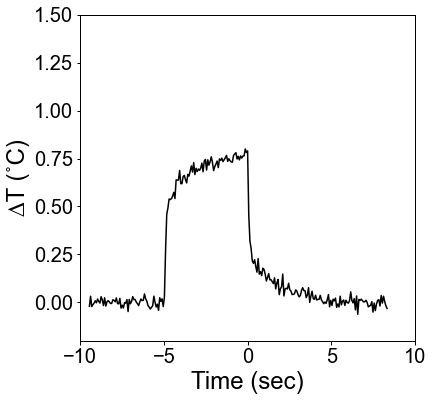

In [66]:
count = 0
ave_tmp_RhoB = 0
data_set_RhoB = pd.DataFrame()
plt.figure(figsize = (6, 6))

for path in files_normal:
    decay = pd.DataFrame(np.array(pd.read_csv(path)[1:], dtype = 'float32'))[1]
    extract = decay[off_time[count] - 135 : off_time[count] + 120]
    coefficient = (np.mean(extract[-10:]) - np.mean(extract[:10]))/255
    extract = (extract - coefficient*range(len(extract))).iloc[:]
    extract = extract/extract.iloc[0]
    extract = extract.reset_index(drop = 'off')
    extract = -np.log(extract/np.mean(extract.iloc[:10]))/0.0351

    data_set_RhoB = pd.concat([data_set_RhoB, extract], axis = 1)
    ave_tmp_RhoB += extract
    count += 1

ave_tmp_RhoB = ave_tmp_RhoB/len(files_normal)
time = [(i-135)*0.07 for i in range(len(ave_tmp_RhoB))]
figmake()
plt.xlim(-10, 10)
plt.ylim(-0.2, 1.5)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.plot(time, ave_tmp_RhoB, color = 'black')
plt.show()

#データの保存
data_set_RhoB.to_csv('RhoB_deltaT_all.csv')

In [67]:
files_path = glob.glob('./FPT/20111*_relaxation_whole_lin22.6_70msec_100mW_5sec/whole_cells/*.csv')
files_path.sort()

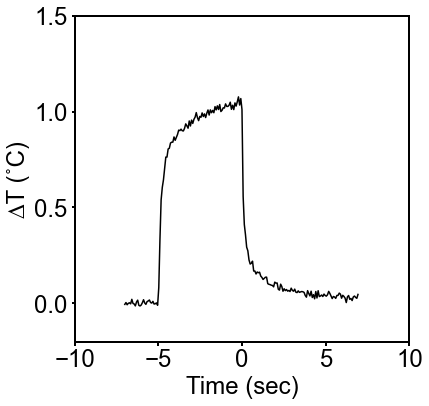

速い成分は0.103851sec
遅い成分は2.538170sec
割合は0.766123
時定数は2.250460


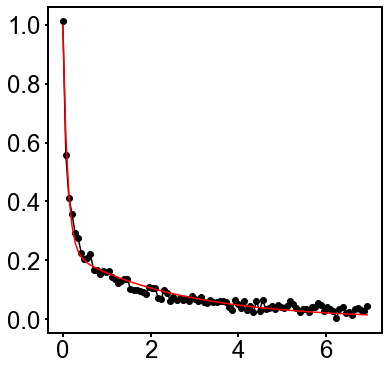

In [68]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_FPT = pd.DataFrame()

#データの平均化
average = np.zeros((1, 200))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+100])
    average += extract
    data_set_FPT = pd.concat([data_set_FPT, pd.DataFrame(extract)], axis = 1)
average_normal = average[0]/len(files_path)
average_normal = average_normal - np.mean(average_normal[:10])
time = [(i-100)*0.07 for i in range(len(average_normal))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal, color = 'Black')
plt.xlim(-10, 10)
plt.ylim(-0.2, 1.5)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()


#温度緩和の時定数の計算
time = [(i)*0.07 for i in range(len(average_normal[100:]))]
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result = curve_fit(relaxation, time ,average_normal[100:])[0]
print('速い成分は%fsec' % result[1])
print('遅い成分は%fsec' % result[2])
print('割合は%f' % result[0])
time_constant = (result[0]*(result[1]**2) + (1-result[0])*(result[2]**2))/(result[0]*result[1] + (1-result[0])*(result[2]))
print('時定数は%f' % time_constant)

plt.figure(figsize = (6, 6))
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal[100:], color = 'Black', marker = 'o')
plt.plot(time, relaxation(np.ravel(time), result[0], result[1], result[2]), color = 'red')
plt.show()

#データの保存
(data_set_FPT - data_set_FPT.iloc[:10, :].mean()).to_csv('FPT_deltaT_all.csv')

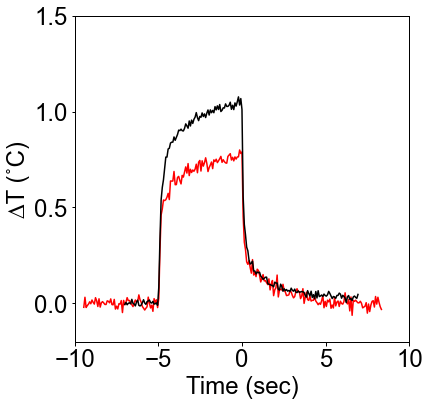

In [69]:
time = [(i-135)*0.07 for i in range(len(ave_tmp_RhoB))]
figmake()
plt.plot(time, ave_tmp_RhoB, color = 'red')

time = [(i-100)*0.07 for i in range(len(average_normal))]

plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal, color = 'Black')
plt.xlim(-10, 10)
plt.ylim(-0.2, 1.5)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()

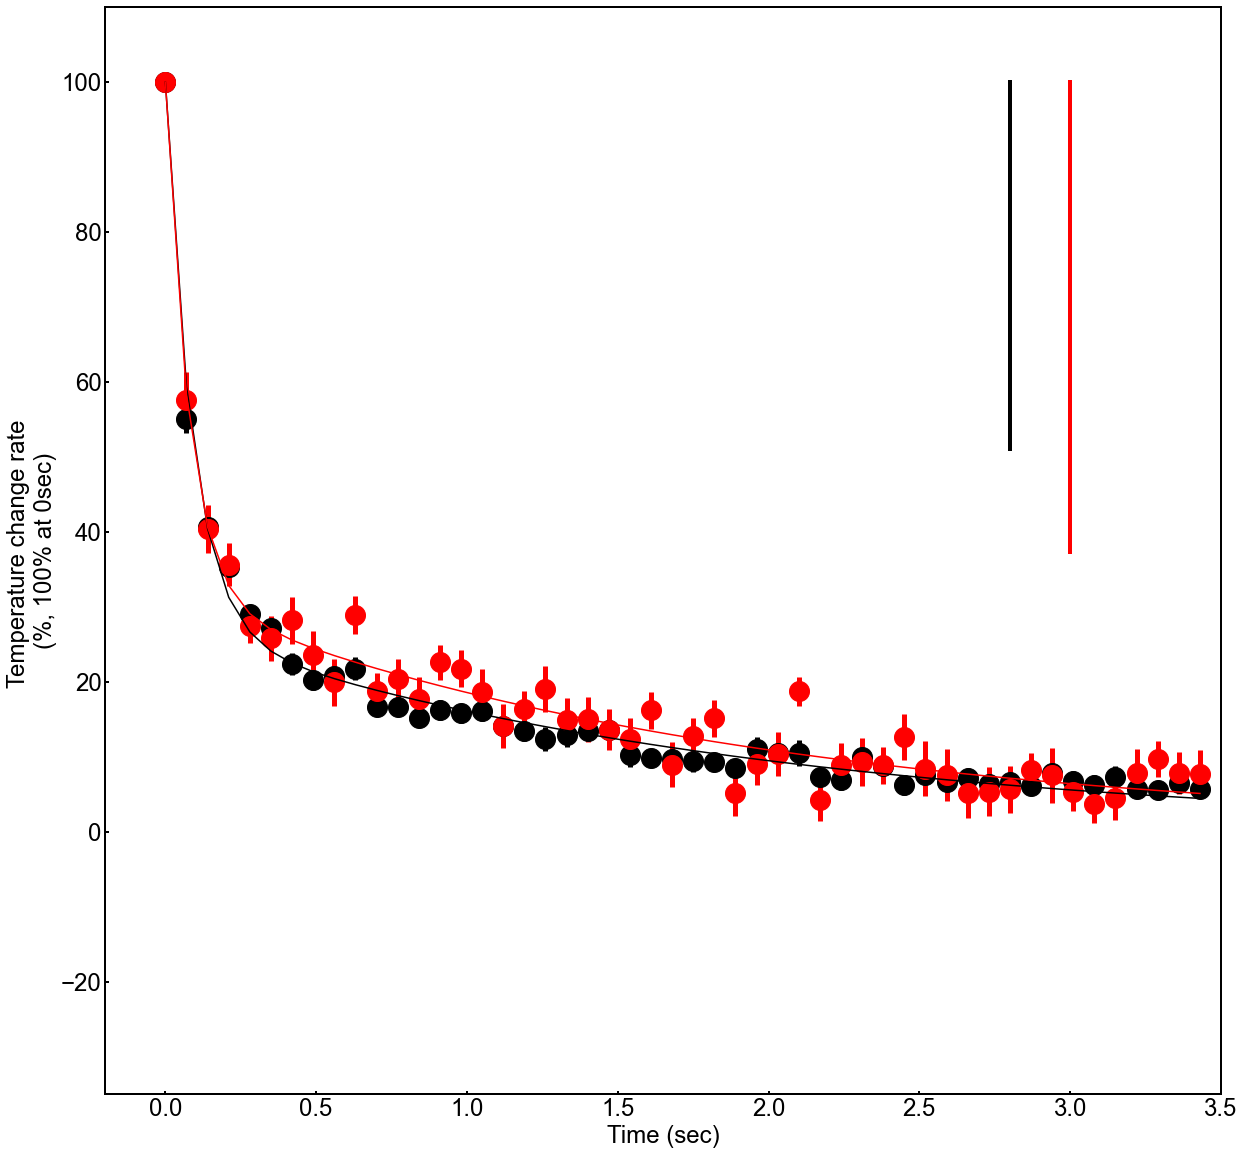

In [70]:
fig = plt.figure(figsize=(20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)


#1˚Cを示すバーを挿入(RhoB)
RhoB_bar = [100- 50/ave_tmp_RhoB[135]*i/100 for i in range(100)]
RhoB_bar_pos = [3.0 for i in range(len(RhoB_bar))]
plt.plot(RhoB_bar_pos, RhoB_bar, linewidth = 4, color = 'red', linestyle = '-')

#1˚Cを示すバーを挿入(FPT)
FPT_bar = [100- 50/average_normal[100]*i/100 for i in range(100)]
FPT_bar_pos = [2.8 for i in range(len(FPT_bar))]
plt.plot(FPT_bar_pos, FPT_bar, linewidth = 4, color = 'black', linestyle = '-')


#SEMの計算(RhoB)
data_set_RhoB = data_set_RhoB/data_set_RhoB.iloc[135, :]*100
sem_RhoB = data_set_RhoB.sem(axis = 1)

#SEMの計算(FPT)
data_set_FPT = data_set_FPT - np.mean(data_set_FPT.iloc[:10, :])
data_set_FPT = data_set_FPT/data_set_FPT.iloc[100, :]*100
sem_FPT = data_set_FPT.sem(axis = 1)


#plotting
time = [i*0.07 for i in range(len(data_set_RhoB[135:]))]
plt.errorbar(time[:50], average_normal[100:150]*100/average_normal[100], yerr = np.ravel(sem_FPT)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time[:50], ave_tmp_RhoB[135:185]*100/ave_tmp_RhoB[135], yerr = np.ravel(sem_RhoB)[135:185], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time[:50], average_normal[100:150]*100/average_normal[100], color = 'Black', marker = 'o', markersize = 20, linewidth = 0)
plt.plot(time[:50], ave_tmp_RhoB[135:185]*100/ave_tmp_RhoB[135], color = 'red', markersize = 20, marker = 'o', linewidth = 0)



#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_FPT = curve_fit(relaxation, time[:50], average_normal[100:150]/average_normal[100])[0]
result_RhoB = curve_fit(relaxation, time[:50], ave_tmp_RhoB[135:185]/ave_tmp_RhoB[135])[0]

#fitting結果の図示
plt.plot(time[:50], relaxation(np.ravel(time[:50]), result_FPT[0], result_FPT[1], result_FPT[2])*100, color = 'black')
plt.plot(time[:50], relaxation(np.ravel(time[:50]), result_RhoB[0], result_RhoB[1], result_RhoB[2])*100, color = 'red')



plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)


#pdfのセーブ
pp = PdfPages('./FigS12_ralaxation.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(average_normal[100:150]*100/average_normal[100]).to_csv('FPT_normed.csv')
pd.DataFrame(ave_tmp_RhoB[135:185]*100/ave_tmp_RhoB[135]).to_csv('RhoB_normed.csv')
(sem_FPT)[100:150].to_csv('sem_FPT.csv')
(sem_RhoB)[135:185].to_csv('sem_RhoB.csv')

In [71]:
#welchのt検定
sum_FPT = data_set_FPT.iloc[102:150].sum().values
sum_RhoB = data_set_RhoB.iloc[137:185].sum().values
sp.stats.ttest_ind(sum_FPT, sum_RhoB, equal_var = False)

Ttest_indResult(statistic=-1.2538408791686235, pvalue=0.2160818649513108)

In [72]:
sem_FPT_bar = (sum_FPT*0.07).std(ddof = 1)/np.sqrt(len(sum_FPT))
sem_RhoB_bar = (sum_RhoB*0.07).std(ddof = 1)/np.sqrt(len(sum_RhoB))

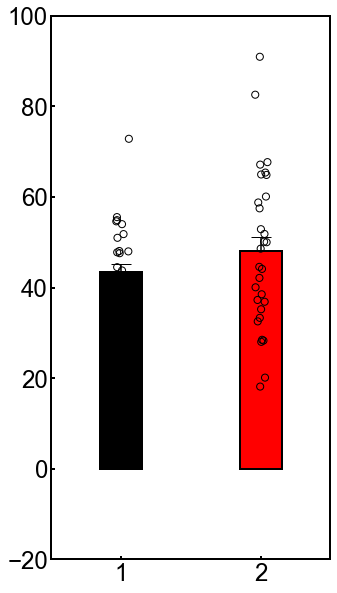

In [73]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_FPT_ave = np.average(sum_FPT*0.07)
sum_RhoB_ave = np.average(sum_RhoB*0.07)
plt.bar(1, sum_FPT_ave, yerr = [[0], [sem_FPT_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_FPT)) 
plt.scatter(x, sum_FPT*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)
plt.bar(2, sum_RhoB_ave, yerr = [[0], [sem_RhoB_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_RhoB)) 
plt.scatter(x, sum_RhoB*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.ylim(-20, 100)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./FigS12_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(sum_FPT*0.07).to_csv('AUC_FPT.csv')
pd.DataFrame(sum_RhoB*0.07).to_csv('AUC_RhoB.csv')

In [74]:
print(sum_FPT_ave)
print(sum_RhoB_ave)

43.32829
48.018781128600686


In [75]:
print(sem_FPT_bar)
print(sem_RhoB_bar)

1.9171741679965841
3.2122861471109347
